Confusion Matrix:
[[339  18]
 [ 36 176]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       357
           1       0.91      0.83      0.87       212

    accuracy                           0.91       569
   macro avg       0.91      0.89      0.90       569
weighted avg       0.91      0.91      0.90       569



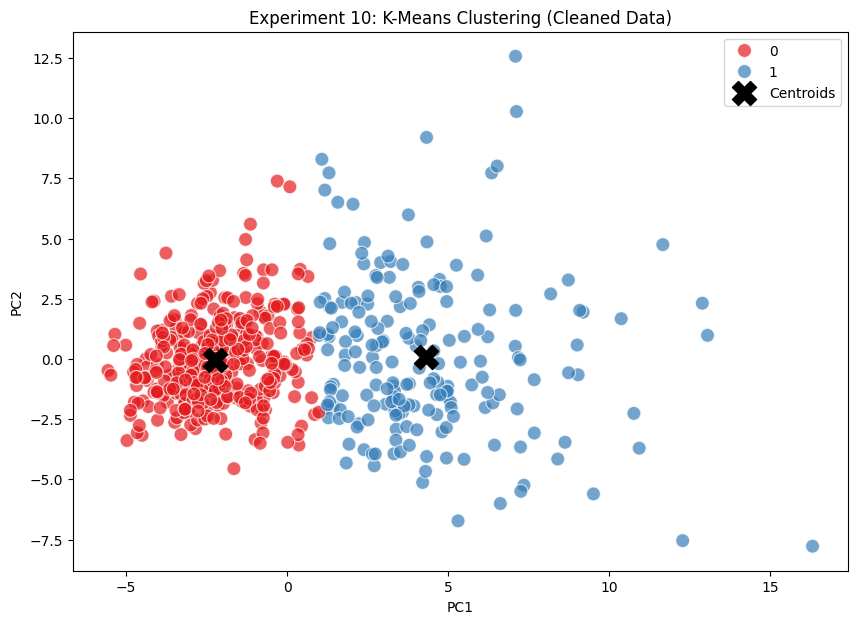

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load the dataset
# Ensure 'Wisconsin Breast Cancer dataset.csv' is in your folder
df_original = pd.read_csv('Wisconsin Breast Cancer dataset.csv')

# 2. Preprocessing
# We drop 'id' and 'diagnosis'
# We also drop any column that is completely empty (fixes the RuntimeWarning)
X = df_original.drop(['id', 'diagnosis'], axis=1)
X = X.dropna(axis=1, how='all') 

# Convert 'M'/'B' to 1/0 for comparison
y = df_original['diagnosis'].map({'M': 1, 'B': 0})

# 3. Scaling (StandardScaler is mandatory for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Apply K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# 5. Print Evaluation Metrics
print("Confusion Matrix:")
print(confusion_matrix(y, y_kmeans))
print("\nClassification Report:")
print(classification_report(y, y_kmeans))

# 6. PCA for Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_plot['Cluster'] = y_kmeans

# 7. Visualization: K-Means with Centroids
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster', palette='Set1', s=100, alpha=0.7)

# Transform centroids to PCA space
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], s=300, c='black', marker='X', label='Centroids')

plt.title('Experiment 10: K-Means Clustering (Cleaned Data)')
plt.legend()
plt.show()

Confusion Matrix:
[[175  37]
 [ 13 344]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       212
           1       0.90      0.96      0.93       357

    accuracy                           0.91       569
   macro avg       0.92      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569



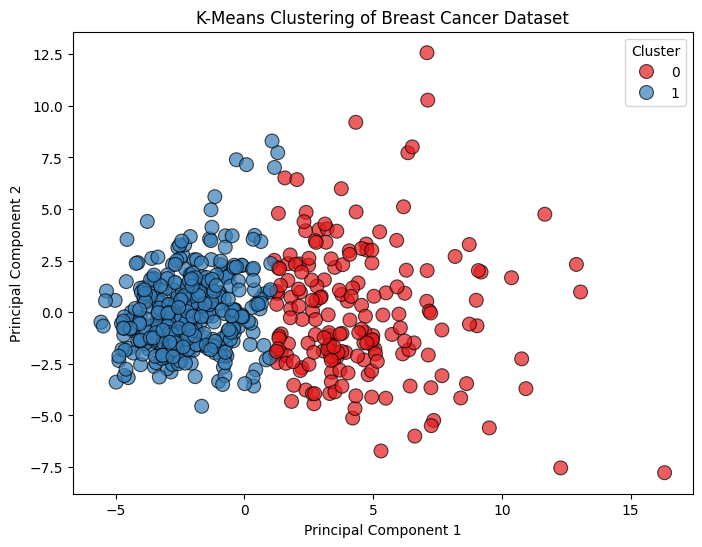

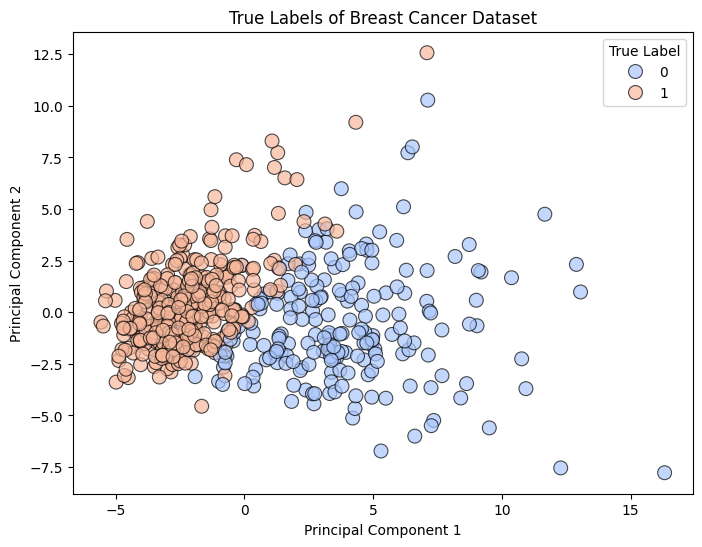

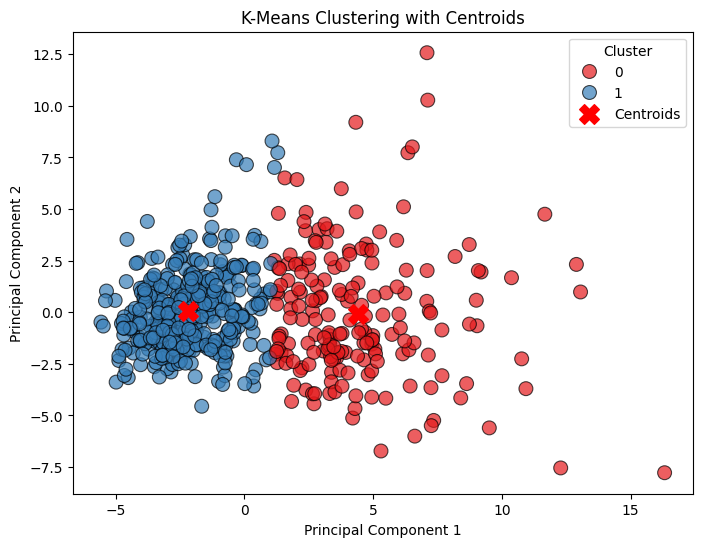

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y, y_kmeans))

print("\nClassification Report:")
print(classification_report(y, y_kmeans))

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame
df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df['Cluster'] = y_kmeans
df['True Label'] = y

# Plot Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster',
                palette='Set1', s=100, edgecolor='black', alpha=0.7)
plt.title('K-Means Clustering of Breast Cancer Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="Cluster")
plt.show()

# Plot True Labels
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='True Label',
                palette='coolwarm', s=100, edgecolor='black', alpha=0.7)
plt.title('True Labels of Breast Cancer Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="True Label")
plt.show()

# Plot with Centroids
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster',
                palette='Set1', s=100, edgecolor='black', alpha=0.7)

centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1],
            s=200, c='red', marker='X', label='Centroids')

plt.title('K-Means Clustering with Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="Cluster")
plt.show()